## Forecasting - Holt-Winters - Retails Sales Among COVID Anomaly

## Code Attribution
<ul>
  <li> Title: Python for Data Analysis 
  <li> Author: Wes McKinney
  <li> Date: 15 February 2026
  <li> Modified By: Charlotte Alley
  <li> Description: Data cleaning, preparation, wrangling, aggregation and group operations, time series and modeling.

### Code Attribution 
<ul>
  <li> Title: Python Code on Holt-Winters Forecasting
  <li> Author: Etqad Khan
  <li> Date: 15 February 2026
  <li> Modified By: Charlotte Alley
  <li> Description: Tutorial on Holt-Winters Forecasting

## Just Following Along in the Holts-Winters Forecasting Tutorial
The tutorial says that patience is the only prerequisite, so let's see what I can muster. It took me a second to realize that the 'tsa' in the stastmodel imports didn't stand for Transportation Security Administration, since they're working with an airline dataset in the tutorial...it's obviously time-series analysis. The dataset is in long form, which isn't very useful for plotting. It makes more sense to convert it to wide format, and then set the month and year as the index, like in the tutorial. There were six missing values, which were dropped in the index setting step. I removed them because the Holts-Winters model requires a complete dataset, and it was only 1% of the total values. 

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [2]:
# Reads in data 
retail = pd.read_csv("us_retail_sales.csv")

In [3]:
# Shows that data is in wide format, not useful for plotting
retail.head()

,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC
0,1992,146925,147223,146805,148032,149010,149800,150761.0,151067.0,152588.0,153521.0,153583.0,155614.0
1,1993,157555,156266,154752,158979,160605,160127,162816.0,162506.0,163258.0,164685.0,166594.0,168161.0
2,1994,167518,169649,172766,173106,172329,174241,174781.0,177295.0,178787.0,180561.0,180703.0,181524.0
3,1995,182413,179488,181013,181686,183536,186081,185431.0,186806.0,187366.0,186565.0,189055.0,190774.0
4,1996,189135,192266,194029,194744,196205,196136,196187.0,196218.0,198859.0,200509.0,200174.0,201284.0


In [4]:
# Checking for missing values, looks like there are some missing values in the
# last half of the year for some years, only 6 values total
retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   YEAR    30 non-null     int64  
 1   JAN     30 non-null     int64  
 2   FEB     30 non-null     int64  
 3   MAR     30 non-null     int64  
 4   APR     30 non-null     int64  
 5   MAY     30 non-null     int64  
 6   JUN     30 non-null     int64  
 7   JUL     29 non-null     float64
 8   AUG     29 non-null     float64
 9   SEP     29 non-null     float64
 10  OCT     29 non-null     float64
 11  NOV     29 non-null     float64
 12  DEC     29 non-null     float64
dtypes: float64(6), int64(7)
memory usage: 3.2 KB


In [5]:
# Melts into long format 
retail = pd.melt(retail, id_vars=['YEAR'], var_name='Month', value_name='Sales')
retail.head()

,YEAR,Month,Sales
0,1992,JAN,146925.0
1,1993,JAN,157555.0
2,1994,JAN,167518.0
3,1995,JAN,182413.0
4,1996,JAN,189135.0


In [6]:
# Creates datetime index from YEAR and Month columns, adds 01 days to silence
# error, drops rows with missing values
retail['Date'] = pd.to_datetime(retail['YEAR'].astype(str) + '-' + 
                                retail['Month'] + '-01', format='%Y-%b-%d')
retail = retail.set_index('Date')[['Sales']].sort_index().dropna()
retail.head()

,Sales
Date,
1992-01-01,146925.0
1992-02-01,147223.0
1992-03-01,146805.0
1992-04-01,148032.0
1992-05-01,149010.0


In [7]:
# Shows now have 354 entries, 360-6 missing values
retail.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 354 entries, 1992-01-01 to 2021-06-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Sales   354 non-null    float64
dtypes: float64(1)
memory usage: 5.5 KB


In [8]:
# Outputs descriptive statistics
retail.describe()

,Sales
count,354.000000
mean,307006.573446
std,94335.828235
min,146805.000000
25%,231402.000000
50%,309534.500000
75%,378193.750000
max,562269.000000


### Data Plot Observations
Hmmmm, I wonder what that large dip in retail sales could be in 2020? I'm just kidding, it's obviously COVID. The other large dip occurs around the great recession, and the adorable little spike that happens in 2002 could be President Bush' call to shop after 9/11. The sharp increase post-COVID is likely due to the boost in online shopping, as well stimulus checks that were distributed during the pandemic. There's also a very clear long term growth pattern, and seasonal fluctuations that appear to get larger over time.

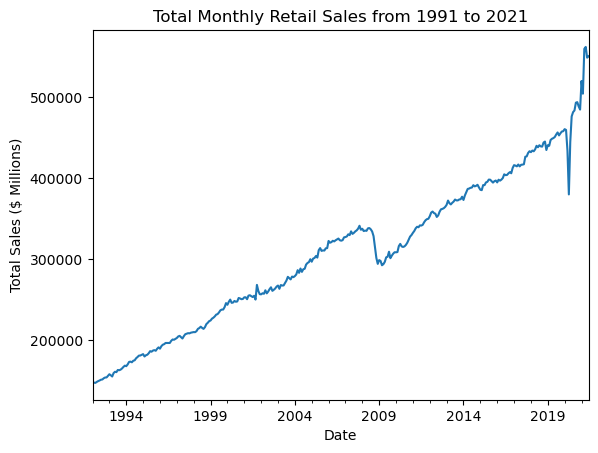

In [9]:
# Plots the sales column against the dated index
retail['Sales'].plot(title='Total Monthly Retail Sales from 1991 to 2021')
plt.ylabel('Total Sales ($ Millions)') 
plt.xlabel('Date')  
plt.show()

### Splitting Data into Training and Test Sets

In [10]:
# Uses the datetime index to split data 
train = retail[retail.index < '2020-07-01']['Sales']
test = retail[retail.index >= '2020-07-01']['Sales']

### Model Fit
Because the dips and peaks tend to increase in magnitude over time, I chose to use the multiplicative argument for both the trend and seasonal arguments. I used 12 for seasonal_periods, because retail sales famously follow a yearly cycle (huge sales during the holidays, etc) and 'MS' for freq, which stands for month-start to include the entire month. 

In [11]:
# Initiates model, uses multiplicative argument because of increased dips and 
# peaks over time, ignoring the warning because the following code still works
model = ExponentialSmoothing(train, trend='mul', seasonal='mul', 
                             seasonal_periods=12, freq='MS')
fitted_model = model.fit()

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


### Model Prediction
Since the freq='MS', this code will produce exactly twelve 'steps' or a year of predicted values. 

In [12]:
# Forecasts predictions for last year of data
predictions = fitted_model.forecast(steps=12)

### Model Evaluation
So the RMSE value doesn't really make sense unless you're comparing it to the overall mean of the set. For that reason, I've used the overall mean previously grabbed from using .describe() on the melted dataset to calculate the percentage error. Honestly, from what I've read about retail, 13% is an acceptable percentage error on retail models. Less than 10% would be better, but with four clear anomolies in this time series (1. Post 9/11 spike, 2. Great Recession drop 3. COVID drop, 4. COVID/Post-COVID spike), the model is doing what it can to find the non-anomalous patterns. Looking at the plot, the test values are themselves outliers, so the predicted values with the Holt-Winters forecast are predicting what sales would have looked like if the pandemic hadn't occured. 

In [13]:
# Runs RMSE on test set, calculates percentage error with overall mean
rmse = ((predictions - test) ** 2).mean() ** 0.5
print(f"RMSE: ${rmse:,.0f} million")
print(f"Percentage Error: {(rmse/307006.57)*100:,.0f}%")

RMSE: $38,868 million
Percentage Error: 13%


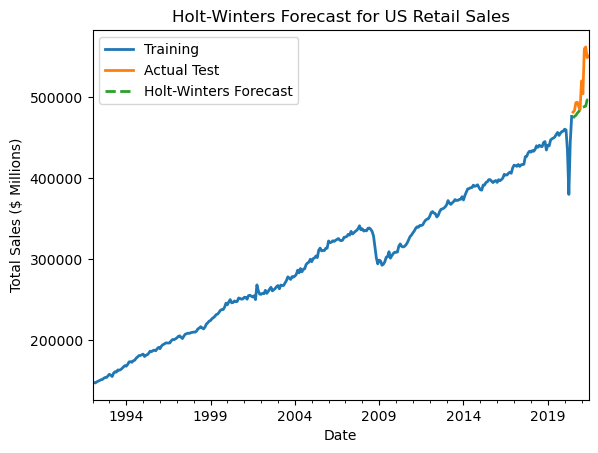

In [14]:
# Plots three lines, the training, test and predicted values
train.plot(label='Training', linewidth=2)
test.plot(label='Actual Test', linewidth=2)
predictions.plot(label='Holt-Winters Forecast', linestyle='--', linewidth=2)
plt.title('Holt-Winters Forecast for US Retail Sales')
plt.ylabel('Total Sales ($ Millions)')
plt.legend() 
plt.show()